# Notebook 14: Within-Paper Junior vs. Senior Analysis (RQ1)

**Research Question:** Do junior and senior co-authors of the *same* award-winning paper
differ in career lift?

- **Junior**: career age ≤ 5 at time of award  
- **Senior**: career age > 5 at time of award  
- **Unit**: author-paper pairs from the same award paper — paper quality, venue, and year are held constant  
- **Outcome**: career lift = mean(citations post-award, years 1–5) / mean(citations pre-award, years −5 to −1)  
- **Test**: Wilcoxon signed-rank on *paper-level* paired differences (junior lift − senior lift)  
- **Source data**: `data/matched/huang_matched_openalex.csv` + `data/profiles/junior_profiles_all.csv`


In [1]:
import pandas as pd
import numpy as np
import json, ast, time, requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

BASE = 'data/'
MAILTO = 'shaheryar.4822@student.uu.se'


## 1. Load Matched Awards (2000–2018)


In [3]:
matched = pd.read_csv("B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\matched\\huang_matched_openalex.csv")
matched = matched[matched['openalex_id'].notna()].copy()
matched = matched[(matched['year'] >= 2000) & (matched['year'] <= 2018)].copy()
matched = matched.reset_index(drop=True)
if 'award_id' not in matched.columns:
    matched['award_id'] = matched.index + 1

print(f'Awards (2000-2018): {len(matched)}')
print(f'Conferences: {matched["conference"].nunique()}')
print(matched['conference'].value_counts())


Awards (2000-2018): 890
Conferences: 30
conference
CHI           185
ICSE           88
FSE            63
UIST           34
PLDI           32
STOC           31
FOCS           30
AAAI           26
ACL            26
IJCAI          25
INFOCOM        24
SOSP           22
NSDI           21
VLDB           21
CVPR           20
KDD            20
PODS           20
OSDI           19
ICML           19
WWW            19
SIGIR          19
SIGMOD         19
CIKM           16
SIGMETRICS     15
NeurIPS        15
SODA           14
SIGCOMM        14
ICCV           12
S&P            11
MOBICOM        10
Name: count, dtype: int64


## 2. Load Existing Junior Profiles


In [4]:
juniors = pd.read_csv("B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\matched\\junior_authors_all_conferences.csv")

# Keep only 2000-2018
juniors = juniors[(juniors['award_year'] >= 2000) & (juniors['award_year'] <= 2018)].copy()

print(f'Junior author rows: {len(juniors)}')
print(f'Unique award papers covered: {juniors["award_id"].nunique()}')
print(juniors.columns.tolist())
print(juniors.head(3))


Junior author rows: 603
Unique award papers covered: 470
['award_id', 'conference', 'award_year', 'work_id', 'award_title', 'author_id', 'author_name', 'author_position', 'career_age_at_award', 'total_pubs_at_award', 'institutions', 'is_corresponding', 'match_route', 'core_rank']
   award_id conference  award_year                           work_id  \
0         1       AAAI        2018  https://openalex.org/W2788603415   
1         2        ACL        2018  https://openalex.org/W2798397965   
2         5        CHI        2018  https://openalex.org/W4255717503   

                                         award_title  \
0           Memory-Augmented Monte Carlo Tree Search   
1  Finding syntax in human encephalography with b...   
2            Agile 3D Sketching with Air Scaffolding   

                          author_id       author_name  author_position  \
0  https://openalex.org/A5014823249      Jincheng Mei                2   
1  https://openalex.org/A5069646529  Adhiguna Kuncoro    

## 3. Collect All-Author Profiles (Junior + Senior)

Notebook 05 only saved *junior* authors. Here we iterate over all matched awards and
collect **all** top-3 author profiles — both juniors and seniors — so we can do the
within-paper paired comparison.

> **Skip this cell** if `data/matched/all_authors_within_paper.csv` already exists.


In [5]:
import os

OUT_PATH = "B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\matched\\all_authors_within_paper.csv"

# ── Helper functions ──────────────────────────────────────────────────────
def get_author_works(author_id):
    all_works = []
    cursor = '*'
    while cursor:
        url = 'https://api.openalex.org/works'
        params = {'filter': f'author.id:{author_id}', 'per-page': 200,
                  'cursor': cursor, 'mailto': MAILTO}
        data = requests.get(url, params=params).json()
        all_works.extend(data.get('results', []))
        cursor = data.get('meta', {}).get('next_cursor')
        if cursor:
            time.sleep(0.05)
    return all_works

def parse_authorships(raw):
    if isinstance(raw, list): return raw
    if not isinstance(raw, str) or raw.strip() in ('', 'nan', '[]'): return []
    try: return json.loads(raw)
    except:
        try: return ast.literal_eval(raw)
        except: return []

def parse_cby(raw):
    if pd.isna(raw): return []
    try: return json.loads(str(raw).replace("'", '"'))
    except: return []

# ── Main collection loop ──────────────────────────────────────────────────
if os.path.exists(OUT_PATH):
    print(f'✓ {OUT_PATH} already exists — loading it.')
    all_authors = pd.read_csv(OUT_PATH)
else:
    records = []
    processed_ids = set()   # avoid duplicate API calls for same author
    author_cache  = {}      # author_id -> counts_by_year str

    for idx, row in matched.iterrows():
        award_id   = row['award_id']
        conference = row['conference']
        award_year = int(row['year'])
        authorships = parse_authorships(row.get('authorships', '[]'))

        for pos_idx, auth in enumerate(authorships[:3], start=1):
            author_id   = auth.get('author', {}).get('id', '')
            author_name = auth.get('author', {}).get('display_name', 'Unknown')
            if not author_id:
                continue
            short_id = author_id.split('/')[-1]

            if short_id in author_cache:
                cby_str, career_age, total_pubs = author_cache[short_id]
            else:
                works = get_author_works(short_id)
                years = [w['publication_year'] for w in works if w.get('publication_year')]
                career_age  = (award_year - min(years)) if years else None
                total_pubs  = len(works)
                # Build counts_by_year
                from collections import defaultdict
                cby = defaultdict(lambda: {'works_count': 0, 'cited_by_count': 0})
                for w in works:
                    yr = w.get('publication_year')
                    if yr:
                        cby[yr]['works_count']    += 1
                        cby[yr]['cited_by_count'] += w.get('cited_by_count', 0)
                cby_list = [{'year': y, 'works_count': v['works_count'],
                             'cited_by_count': v['cited_by_count']} for y, v in sorted(cby.items())]
                cby_str = json.dumps(cby_list)
                author_cache[short_id] = (cby_str, career_age, total_pubs)
                time.sleep(0.05)

            seniority = 'junior' if (career_age is not None and career_age <= 5) else 'senior'

            records.append({
                'award_id':      award_id,
                'conference':    conference,
                'award_year':    award_year,
                'author_id':     short_id,
                'author_name':   author_name,
                'position':      pos_idx,
                'career_age':    career_age,
                'total_pubs':    total_pubs,
                'seniority':     seniority,
                'counts_by_year': cby_str,
            })

        if (idx + 1) % 50 == 0:
            print(f'  {idx+1}/{len(matched)} awards processed — {len(records)} author rows')

    all_authors = pd.DataFrame(records)
    all_authors.to_csv(OUT_PATH, index=False)
    print(f'\n✓ Saved {len(all_authors)} rows to {OUT_PATH}')

print(all_authors['seniority'].value_counts())
print(f'Award papers: {all_authors["award_id"].nunique()}')


  50/890 awards processed — 129 author rows
  100/890 awards processed — 264 author rows
  150/890 awards processed — 397 author rows
  200/890 awards processed — 529 author rows
  250/890 awards processed — 668 author rows
  300/890 awards processed — 807 author rows
  350/890 awards processed — 937 author rows
  400/890 awards processed — 1073 author rows
  450/890 awards processed — 1196 author rows
  500/890 awards processed — 1323 author rows
  550/890 awards processed — 1462 author rows
  600/890 awards processed — 1587 author rows
  650/890 awards processed — 1708 author rows
  700/890 awards processed — 1838 author rows
  750/890 awards processed — 1965 author rows
  800/890 awards processed — 2084 author rows
  850/890 awards processed — 2202 author rows

✓ Saved 2291 rows to B:\Semester 4 UU\thesis-best-paper-trajectories\data\matched\all_authors_within_paper.csv
seniority
senior    1665
junior     626
Name: count, dtype: int64
Award papers: 878


## 4. Filter to Papers with Both Junior and Senior Authors

The within-paper design requires at least one junior **and** one senior on the same paper.


In [6]:
paper_groups = all_authors.groupby('award_id')['seniority'].apply(set)
mixed_ids    = paper_groups[paper_groups.apply(lambda s: 'junior' in s and 'senior' in s)].index

df_mixed = all_authors[all_authors['award_id'].isin(mixed_ids)].copy()

print(f'Total award papers:               {all_authors["award_id"].nunique()}')
print(f'Papers with only juniors:         {(paper_groups.apply(lambda s: s == {"junior"}).sum())}')
print(f'Papers with only seniors:         {(paper_groups.apply(lambda s: s == {"senior"}).sum())}')
print(f'Papers with BOTH (within-paper):  {len(mixed_ids)}')
print(f'Author rows in mixed papers:      {len(df_mixed)}')
print(df_mixed['seniority'].value_counts())


Total award papers:               878
Papers with only juniors:         39
Papers with only seniors:         394
Papers with BOTH (within-paper):  445
Author rows in mixed papers:      1257
seniority
senior    708
junior    549
Name: count, dtype: int64


## 5. Compute Career Lift per Author

Lift = mean(citations in years +1 to +5) / mean(citations in years −5 to −1).  
Authors without enough pre- or post-award data are excluded.


In [7]:
def compute_lift(cby_raw, award_year, pre_window=(-5,-1), post_window=(1,5)):
    entries = parse_cby(cby_raw)
    pre  = [e['cited_by_count'] for e in entries
            if pre_window[0]  <= (e['year'] - award_year) <= pre_window[1]]
    post = [e['cited_by_count'] for e in entries
            if post_window[0] <= (e['year'] - award_year) <= post_window[1]]
    if not pre or not post:
        return np.nan
    pre_mean  = np.mean(pre)
    post_mean = np.mean(post)
    if pre_mean == 0:
        return np.nan
    return post_mean / pre_mean

def compute_pub_lift(cby_raw, award_year, pre_window=(-5,-1), post_window=(1,5)):
    entries = parse_cby(cby_raw)
    pre  = [e['works_count'] for e in entries
            if pre_window[0]  <= (e['year'] - award_year) <= pre_window[1]]
    post = [e['works_count'] for e in entries
            if post_window[0] <= (e['year'] - award_year) <= post_window[1]]
    if not pre or not post:
        return np.nan
    pre_mean  = np.mean(pre)
    post_mean = np.mean(post)
    if pre_mean == 0:
        return np.nan
    return post_mean / pre_mean

df_mixed = df_mixed.copy()
df_mixed['cite_lift'] = df_mixed.apply(
    lambda r: compute_lift(r['counts_by_year'], r['award_year']), axis=1)
df_mixed['pub_lift'] = df_mixed.apply(
    lambda r: compute_pub_lift(r['counts_by_year'], r['award_year']), axis=1)

print(df_mixed[['seniority','cite_lift','pub_lift']].groupby('seniority').describe())


          cite_lift                                                          \
              count      mean        std  min       25%       50%       75%   
seniority                                                                     
junior        397.0  6.048862  15.318339  0.0  0.645904  1.522449  3.716667   
senior        678.0  3.832358  25.577789  0.0  0.441430  0.823196  1.768556   

                 pub_lift                                                    \
             max    count      mean       std       min       25%       50%   
seniority                                                                     
junior     175.6    410.0  2.046131  1.810926  0.210526  1.000000  1.556119   
senior     569.6    687.0  1.590316  1.250272  0.133929  0.825121  1.230769   

                                
                75%        max  
seniority                       
junior     2.500000  17.750000  
senior     1.933333   9.333333  


## 6. Build Paper-Level Paired Differences

For each paper, compute the *representative* junior and senior lift  
(median across all juniors / seniors on that paper), then compute the difference.


In [8]:
paper_lift = (
    df_mixed.dropna(subset=['cite_lift'])
    .groupby(['award_id', 'seniority'])['cite_lift']
    .median()
    .unstack('seniority')
    .dropna()          # keep only papers with both groups having valid lift
    .reset_index()
)

paper_pub = (
    df_mixed.dropna(subset=['pub_lift'])
    .groupby(['award_id', 'seniority'])['pub_lift']
    .median()
    .unstack('seniority')
    .dropna()
    .reset_index()
)

print(f'Papers with valid citation pairs: {len(paper_lift)}')
print(f'Papers with valid publication pairs: {len(paper_pub)}')
print('\nMedian lifts (citation):')
print(f'  Junior: {paper_lift["junior"].median():.3f}')
print(f'  Senior: {paper_lift["senior"].median():.3f}')


Papers with valid citation pairs: 347
Papers with valid publication pairs: 357

Median lifts (citation):
  Junior: 1.616
  Senior: 0.932


## 7. Wilcoxon Signed-Rank Test


In [9]:
# Citation lift
stat_c, p_c = stats.wilcoxon(paper_lift['junior'], paper_lift['senior'])

# Publication lift
stat_p, p_p = stats.wilcoxon(paper_pub['junior'], paper_pub['senior'])

print('=== Wilcoxon Signed-Rank Test (within-paper paired) ===')
print(f'\nCitation Lift:')
print(f'  Junior median:  {paper_lift["junior"].median():.3f}')
print(f'  Senior median:  {paper_lift["senior"].median():.3f}')
print(f'  Wilcoxon W={stat_c:.1f},  p={p_c:.4f}')
print(f'  {"Significant" if p_c < 0.05 else "Not significant"} at α=0.05')

print(f'\nPublication Lift:')
print(f'  Junior median:  {paper_pub["junior"].median():.3f}')
print(f'  Senior median:  {paper_pub["senior"].median():.3f}')
print(f'  Wilcoxon W={stat_p:.1f},  p={p_p:.4f}')
print(f'  {"Significant" if p_p < 0.05 else "Not significant"} at α=0.05')


=== Wilcoxon Signed-Rank Test (within-paper paired) ===

Citation Lift:
  Junior median:  1.616
  Senior median:  0.932
  Wilcoxon W=18888.0,  p=0.0000
  Significant at α=0.05

Publication Lift:
  Junior median:  1.650
  Senior median:  1.265
  Wilcoxon W=23078.5,  p=0.0000
  Significant at α=0.05


## 8. Trajectory Plots (±5 years)


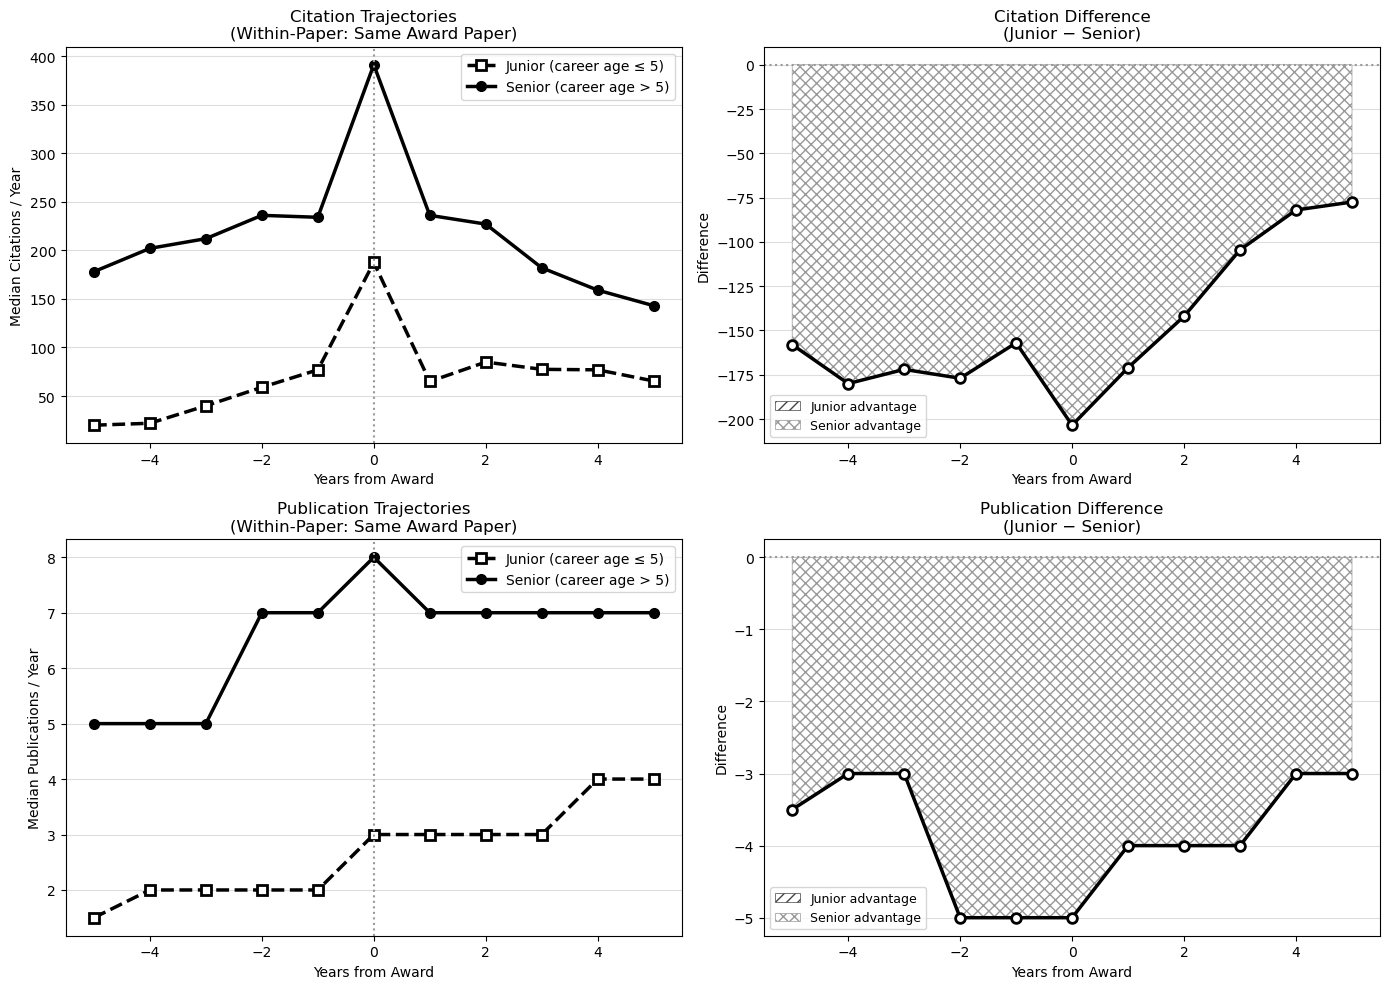

Saved: data/figures/14_within_paper_trajectories.png


In [11]:
# Build year-by-year trajectories
rows = []
for _, r in df_mixed.iterrows():
    for e in parse_cby(r['counts_by_year']):
        rel = e['year'] - r['award_year']
        if -5 <= rel <= 5:
            rows.append({'rel_year': rel, 'citations': e['cited_by_count'],
                         'works': e['works_count'], 'seniority': r['seniority']})
traj = pd.DataFrame(rows)

summary = (traj.groupby(['rel_year', 'seniority'])
               .agg(med_cites=('citations','median'),
                    med_works=('works','median'),
                    n=('citations','count'))
               .reset_index())

style = {
    'junior': dict(color='black', ls='--', marker='s', ms=7,
                   mfc='white', mec='black', mew=2, label='Junior (career age ≤ 5)'),
    'senior': dict(color='black', ls='-',  marker='o', ms=7,
                   mfc='black',  label='Senior (career age > 5)'),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Citation trajectories ──
ax = axes[0, 0]
for sen in ['junior', 'senior']:
    sub = summary[summary['seniority'] == sen]
    ax.plot(sub['rel_year'], sub['med_cites'], lw=2.5, **style[sen])
ax.axvline(0, color='#999', ls=':', lw=1.5)
ax.set_title('Citation Trajectories\n(Within-Paper: Same Award Paper)')
ax.set_xlabel('Years from Award'); ax.set_ylabel('Median Citations / Year')
ax.legend(); ax.yaxis.grid(True, color='#ddd'); ax.set_axisbelow(True)

# ── Citation difference ──
ax = axes[0, 1]
diff = summary.pivot(index='rel_year', columns='seniority', values='med_cites')  # ← fixed
d = diff['junior'] - diff['senior']
ax.plot(d.index, d.values, 'o-', lw=2.5, color='black', ms=7, mfc='white', mew=2)
ax.axhline(0, color='#999', ls=':', lw=1.5)
ax.fill_between(d.index, d.values, 0, where=d.values>=0,
                hatch='///', fc='white', ec='#444', lw=0.5, label='Junior advantage')
ax.fill_between(d.index, d.values, 0, where=d.values<0,
                hatch='xxx', fc='white', ec='#999', lw=0.5, label='Senior advantage')
ax.set_title('Citation Difference\n(Junior − Senior)')
ax.set_xlabel('Years from Award'); ax.set_ylabel('Difference')
ax.legend(fontsize=9); ax.yaxis.grid(True, color='#ddd'); ax.set_axisbelow(True)

# ── Publication trajectories ──
ax = axes[1, 0]
for sen in ['junior', 'senior']:
    sub = summary[summary['seniority'] == sen]
    ax.plot(sub['rel_year'], sub['med_works'], lw=2.5, **style[sen])
ax.axvline(0, color='#999', ls=':', lw=1.5)
ax.set_title('Publication Trajectories\n(Within-Paper: Same Award Paper)')
ax.set_xlabel('Years from Award'); ax.set_ylabel('Median Publications / Year')
ax.legend(); ax.yaxis.grid(True, color='#ddd'); ax.set_axisbelow(True)

# ── Publication difference ──
ax = axes[1, 1]
diff_p = summary.pivot(index='rel_year', columns='seniority', values='med_works')  # ← fixed
dp = diff_p['junior'] - diff_p['senior']
ax.plot(dp.index, dp.values, 'o-', lw=2.5, color='black', ms=7, mfc='white', mew=2)
ax.axhline(0, color='#999', ls=':', lw=1.5)
ax.fill_between(dp.index, dp.values, 0, where=dp.values>=0,
                hatch='///', fc='white', ec='#444', lw=0.5, label='Junior advantage')
ax.fill_between(dp.index, dp.values, 0, where=dp.values<0,
                hatch='xxx', fc='white', ec='#999', lw=0.5, label='Senior advantage')
ax.set_title('Publication Difference\n(Junior − Senior)')
ax.set_xlabel('Years from Award'); ax.set_ylabel('Difference')
ax.legend(fontsize=9); ax.yaxis.grid(True, color='#ddd'); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\figures\\14_within_paper_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: data/figures/14_within_paper_trajectories.png')


## 9. Lift Distribution (Boxplot)


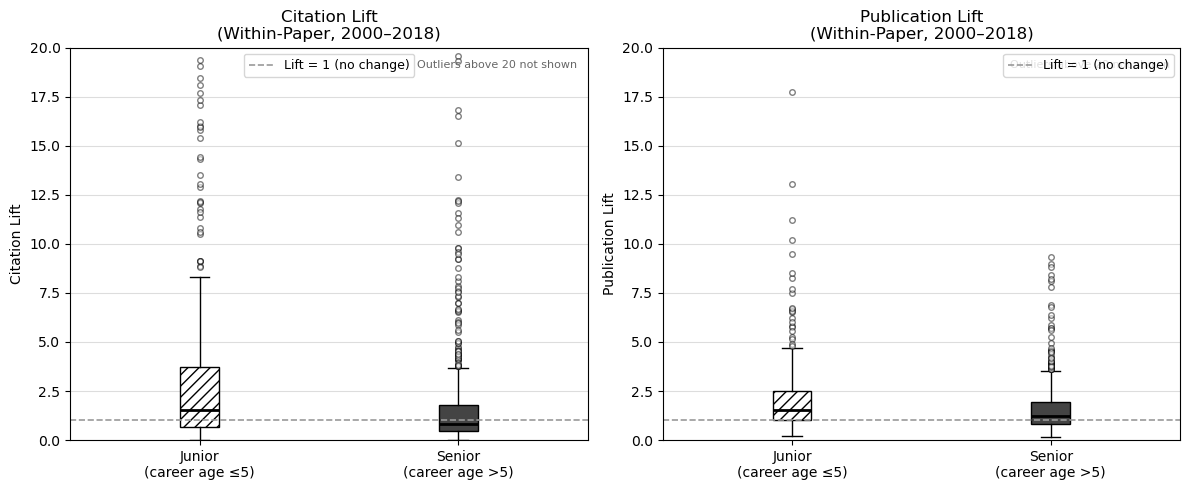

Saved: data/figures/14_within_paper_boxplot.png


In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for ax, metric, label in [
    (ax1, 'cite_lift', 'Citation Lift'),
    (ax2, 'pub_lift',  'Publication Lift'),
]:
    data_j = df_mixed[df_mixed['seniority']=='junior'][metric].dropna()
    data_s = df_mixed[df_mixed['seniority']=='senior'][metric].dropna()

    bp = ax.boxplot([data_j, data_s],
                    labels=['Junior\n(career age ≤5)', 'Senior\n(career age >5)'],
                    patch_artist=True,
                    medianprops=dict(color='black', lw=2),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'),
                    flierprops=dict(marker='o', markerfacecolor='white',
                                   markeredgecolor='black', ms=4, alpha=0.5),
                    showfliers=True)

    bp['boxes'][0].set(facecolor='white', edgecolor='black', hatch='///')
    bp['boxes'][1].set(facecolor='#444',  edgecolor='black')
    ax.set_ylim(0, 20)   # or use symlog scale
    # add a note that X outliers above 20 are not shown
    ax.text(0.98, 0.97, f'Outliers above 20 not shown', 
            transform=ax.transAxes, ha='right', va='top', fontsize=8, color='#666')
    ax.axhline(1.0, color='#999', ls='--', lw=1.2, label='Lift = 1 (no change)')
    ax.set_title(f'{label}\n(Within-Paper, 2000–2018)')
    ax.set_ylabel(label)
    ax.yaxis.grid(True, color='#ddd'); ax.set_axisbelow(True)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\figures\\14_within_paper_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: data/figures/14_within_paper_boxplot.png')


## 10. Conference-Level Breakdown


In [16]:
conf_lift = (
    df_mixed.dropna(subset=['cite_lift'])
    .groupby(['conference', 'seniority'])['cite_lift']
    .median()
    .unstack('seniority')
    .dropna()
)
conf_lift['diff_junior_minus_senior'] = conf_lift['junior'] - conf_lift['senior']
conf_lift = conf_lift.sort_values('diff_junior_minus_senior', ascending=False)

print(conf_lift.round(3).to_string())
conf_lift.reset_index().to_csv('B:\\Semester 4 UU\\thesis-best-paper-trajectories\\data\\figures\\14_conf_lift_breakdown.csv', index=False)
print('\nSaved: data/figures/14_conf_lift_breakdown.csv')


seniority   junior  senior  diff_junior_minus_senior
conference                                          
NeurIPS      8.883   1.734                     7.149
NSDI         3.204   0.377                     2.827
FOCS         3.288   0.544                     2.745
S&P          3.145   0.497                     2.648
SIGMETRICS   3.290   0.672                     2.619
PODS         2.996   0.753                     2.243
ACL          2.572   0.798                     1.774
SOSP         2.162   0.712                     1.450
ICCV         2.914   1.571                     1.343
ICML         2.444   1.181                     1.264
CVPR         3.459   2.335                     1.124
AAAI         1.776   0.683                     1.093
IJCAI        1.867   0.852                     1.015
SIGIR        2.525   1.530                     0.995
OSDI         1.716   0.843                     0.873
INFOCOM      1.578   0.715                     0.863
STOC         1.375   0.562                    

## 11. Summary of Findings

| | Junior | Senior | p-value |
|---|---|---|---|
| Median Citation Lift | *see output above* | *see output above* | *see above* |
| Median Publication Lift | *see output above* | *see output above* | *see above* |

**Interpretation:**
- If `p > 0.05`: no significant difference → award benefits are shared equally on the same paper
- If `p < 0.05 and junior > senior`: award disproportionately boosts junior careers
- If `p < 0.05 and senior > junior`: award disproportionately boosts senior careers (Matthew effect)
